In [1]:
from matplotlib import pyplot as plt

from fixed_rate_bond import duration, make_schedule, make_cashflows, convexity, price, discount_cashflows, \
    yield_to_maturity
import numpy as np

In [2]:
first_coupon_date = "2023-06-15"
maturity_date = "2033-06-15"
num_payments_per_year = 12
yearly_rate = 0.045
nominal = 1000
zero_rates = np.array([0.018, 0.02, 0.021, 0.022, 0.023, 0.024, 0.025, 0.0257, 0.0265, 0.027])

schedule = make_schedule(first_coupon_date, maturity_date, frequency = str(num_payments_per_year)+"MS")
bond = make_cashflows(schedule, yearly_rate, nominal, num_payments_per_year)

In [3]:
print(discount_cashflows(bond, zero_rates))
print(price(bond, zero_rates))

            Cashflows  Discount Factors  Discounted Cashflows
2023-07-15       45.0          1.000000             45.000000
2024-07-15       45.0          0.980392             44.117647
2025-07-15       45.0          0.959287             43.167911
2026-07-15       45.0          0.936801             42.156042
2027-07-15       45.0          0.913056             41.087525
2028-07-15       45.0          0.888178             39.968029
2029-07-15       45.0          0.862297             38.803359
2030-07-15       45.0          0.837255             37.676454
2031-07-15       45.0          0.811201             36.504036
2032-07-15     1045.0          0.786803            822.209136
1190.6901383603115


$$ y= - \frac{\Delta D}{\Delta c} $$

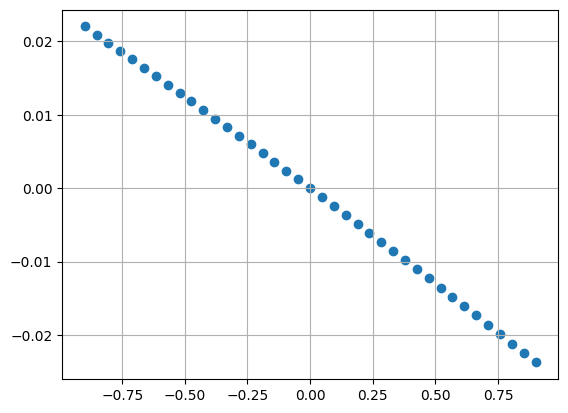

-0.02544811223818199 -0.0003023987873199566


In [4]:
rate_changes = np.linspace(-0.9, 0.9, 39)
cg_durations = np.zeros_like(rate_changes)
durations = np.zeros_like(rate_changes)

baseline_duration = duration(bond,zero_rates)

for i in range(len(rate_changes)):
    durations[i] = duration(bond, (1+rate_changes[i])*zero_rates)
    cg_durations[i] = (durations[i]-baseline_duration)/baseline_duration

plt.scatter(rate_changes, cg_durations)
plt.grid()
plt.show()

m, b = np.polyfit(rate_changes, cg_durations, deg=1)

print(m,b)

In [5]:
y = yield_to_maturity(bond, zero_rates)
print(y)

0.026585219599661595


$$ \frac{\Delta P}{P} \simeq - D \Delta y + \frac{1}{2} C \Delta y^2$$

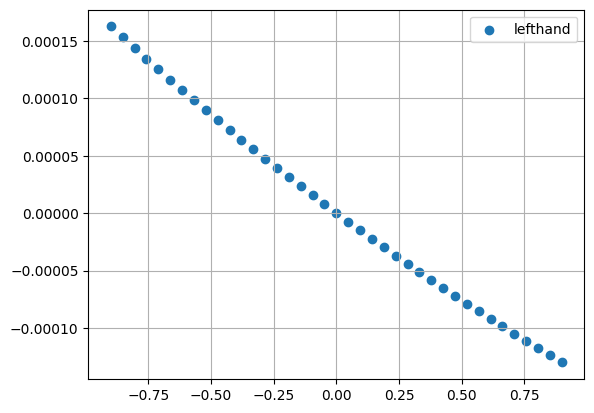

In [12]:
baseline_price = price(bond,zero_rates)
baseline_convexity = convexity(bond,zero_rates)
baseline_yield = yield_to_maturity(bond, zero_rates)
cg_prices = np.zeros_like(rate_changes)
cg_yield = np.zeros_like(rate_changes)

for i in range(len(rate_changes)):
    cg_prices[i] = (price(bond,zero_rates*(1+rate_changes[i])) - baseline_price)/baseline_price
    cg_yield[i] = (yield_to_maturity(bond,zero_rates*(1+rate_changes[i])) - baseline_yield)/baseline_yield

plt.scatter(rate_changes,cg_prices/baseline_price,  label = "lefthand")
#plt.scatter(rate_changes,-baseline_duration*cg_yield, label = "righthand")
#plt.scatter(rate_changes,-baseline_duration*cg_yield + baseline_convexity/2*cg_yield**2, label = "righthand")
plt.legend()
plt.grid()
plt.show()